In [1]:
import os
import torch

BASE_PATH = r"C:\Users\HP\Desktop\GAVE2_preliminary"

TRAIN_IMAGE_DIR = os.path.join(BASE_PATH, "training", "images")
TRAIN_AV_DIR = os.path.join(BASE_PATH, "training", "av")
TRAIN_MASK_DIR = os.path.join(BASE_PATH, "training", "masks")

VAL_IMAGE_DIR = os.path.join(BASE_PATH, "validation", "images")
VAL_AV_DIR = os.path.join(BASE_PATH, "validation", "av")
VAL_MASK_DIR = os.path.join(BASE_PATH, "validation", "masks")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_W = 768
IMG_H = 512

BATCH_SIZE = 1
LR = 1e-4
EPOCHS = 200

print(DEVICE)

cuda


In [2]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from tqdm import tqdm

from scipy import ndimage
from skimage.morphology import disk

In [3]:
all_files = sorted(os.listdir(TRAIN_IMAGE_DIR))

train_files, temp_files = train_test_split(
    all_files,
    test_size=0.30,
    random_state=42
)

val_files, test_files = train_test_split(
    temp_files,
    test_size=0.50,
    random_state=42
)

print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))

Train: 35
Val: 7
Test: 8


In [4]:
print(os.listdir(BASE_PATH))
print(len(os.listdir(TRAIN_IMAGE_DIR)))
print(len(os.listdir(TRAIN_AV_DIR)))
print(len(os.listdir(TRAIN_MASK_DIR)))

['00_Data_Split.ipynb', '01_Baseline_Raw.ipynb', '02_Preprocessed_AV_Segmentation.ipynb', '03_Augmentation_Preprocessing_AV.ipynb', '04_Loss_Experiments.ipynb', '05_Final_AV_Model.ipynb', '06_Hyperparameter_Tuning_CLDice.ipynb', '07_CLDice_Loss_Experiments.ipynb', '08_ViT_RRW_Preprocessing_Final.ipynb', '09_RRWNET_Final.ipynb', '10_final.ipynb', '11_fullNfinal.ipynb', 'archives', 'baseline_best.pth', 'best_aug_av_model.pth', 'best_av_model.pth', 'best_exp6_trialA.pth', 'best_final_av_model.pth', 'best_final_model.pth', 'best_rrwnet.pth', 'best_rrwnet_gave2.pth', 'best_rrwnet_true.pth', 'best_vit_model.pth', 'dataset_split.pkl', 'training', 'validation']
50
50
50


In [5]:
all_files = sorted(os.listdir(TRAIN_IMAGE_DIR))

train_files, temp_files = train_test_split(
    all_files,
    test_size=0.30,
    random_state=42
)

val_files, test_files = train_test_split(
    temp_files,
    test_size=0.50,
    random_state=42
)

print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))

Train: 35
Val: 7
Test: 8


In [6]:
def crop_center(img, cropx, cropy):
    y, x = img.shape[:2]
    startx = x // 2 - cropx // 2
    starty = y // 2 - cropy // 2
    return img[starty:starty+cropy, startx:startx+cropx]


def to_0_1(img):
    return (img - img.min()) / (img.max() - img.min() + 1e-8)

In [7]:
def rrwnet_preprocess(img, mask, disk_size=5):
    img = img.astype(np.float32) / 255.0
    mask = (mask > 0).astype(np.float32)

    original = img.copy()

    zoomed = Image.fromarray((original * 255).astype(np.uint8))
    zoomed = zoomed.resize(
        (int(original.shape[1] * 1.15), int(original.shape[0] * 1.15)),
        Image.BICUBIC
    )
    zoomed = np.array(zoomed) / 255.0
    zoomed = crop_center(zoomed, original.shape[1], original.shape[0])

    kernel = disk(disk_size)
    mask_eroded = ndimage.binary_erosion(mask, kernel).astype(np.float32)

    img_copy = original.copy()
    img_copy[mask_eroded < 1] = 0.0

    mask_rgb = np.stack([mask_eroded]*3, axis=-1)

    composed = mask_rgb.copy()
    composed[mask_rgb == 1] = img_copy[mask_rgb == 1]
    composed[mask_rgb < 1] = zoomed[mask_rgb < 1]

    filtered = ndimage.gaussian_filter(composed, sigma=(10,10,0))

    subtracted = composed - filtered
    subtracted[mask_rgb < 1] = 0

    enhanced = subtracted / (np.std(subtracted) + 1e-8)
    enhanced = to_0_1(enhanced)
    enhanced[mask_rgb < 1] = 0

    return enhanced, mask_eroded

In [8]:
def av_to_3channel(av):
    rgb = av[:, :, :3]

    red = np.all(rgb == [255, 0, 0], axis=-1)
    blue = np.all(rgb == [0, 0, 255], axis=-1)
    green = np.all(rgb == [0, 255, 0], axis=-1)

    artery = (red | green).astype(np.float32)
    vein = (blue | green).astype(np.float32)
    vessel = (red | blue | green).astype(np.float32)

    gt = np.stack([artery, vein, vessel], axis=0)
    return gt

In [9]:
class GAVE2Dataset(Dataset):
    def __init__(self, file_list):
        self.file_list = file_list

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fname = self.file_list[idx]

        img = np.array(Image.open(os.path.join(TRAIN_IMAGE_DIR, fname)).convert("RGB"))
        av = np.array(Image.open(os.path.join(TRAIN_AV_DIR, fname)))
        mask = np.array(Image.open(os.path.join(TRAIN_MASK_DIR, fname)))

        img, roi = rrwnet_preprocess(img, mask)

        img = cv2.resize(img, (IMG_W, IMG_H))
        roi = cv2.resize(roi, (IMG_W, IMG_H), interpolation=cv2.INTER_NEAREST)

        gt = av_to_3channel(av)
        gt = np.transpose(gt, (1,2,0))
        gt = cv2.resize(gt, (IMG_W, IMG_H), interpolation=cv2.INTER_NEAREST)
        gt = np.transpose(gt, (2,0,1))

        img = np.transpose(img, (2,0,1))

        img = torch.tensor(img, dtype=torch.float32)
        gt = torch.tensor(gt, dtype=torch.float32)
        roi = torch.tensor(roi[None], dtype=torch.float32)

        return img, gt, roi

In [10]:
train_dataset = GAVE2Dataset(train_files)
val_dataset = GAVE2Dataset(val_files)
test_dataset = GAVE2Dataset(test_files)


In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

In [12]:
images, targets, rois = next(iter(train_loader))

print(images.shape)
print(targets.shape)
print(rois.shape)


torch.Size([1, 3, 512, 768])
torch.Size([1, 3, 512, 768])
torch.Size([1, 1, 512, 768])


In [13]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UpConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)

    def forward(self, x):
        return self.up(x)

In [14]:
class UNetModule(nn.Module):
    def __init__(self, input_ch, output_ch, base_ch=64):
        super().__init__()

        self.conv1 = ConvBlock(input_ch, base_ch)
        self.conv2 = ConvBlock(base_ch, base_ch*2)
        self.conv3 = ConvBlock(base_ch*2, base_ch*4)
        self.conv4 = ConvBlock(base_ch*4, base_ch*8)
        self.conv5 = ConvBlock(base_ch*8, base_ch*16)

        self.up1 = UpConv(base_ch*16, base_ch*8)
        self.conv6 = ConvBlock(base_ch*16, base_ch*8)

        self.up2 = UpConv(base_ch*8, base_ch*4)
        self.conv7 = ConvBlock(base_ch*8, base_ch*4)

        self.up3 = UpConv(base_ch*4, base_ch*2)
        self.conv8 = ConvBlock(base_ch*4, base_ch*2)

        self.up4 = UpConv(base_ch*2, base_ch)
        self.conv9 = ConvBlock(base_ch*2, base_ch)

        self.outconv = nn.Conv2d(base_ch, output_ch, kernel_size=1)

    def forward(self, x):
        x1 = self.conv1(x)
        x2 = self.conv2(F.max_pool2d(x1, 2))
        x3 = self.conv3(F.max_pool2d(x2, 2))
        x4 = self.conv4(F.max_pool2d(x3, 2))
        x5 = self.conv5(F.max_pool2d(x4, 2))

        x = self.up1(x5)
        x = torch.cat([x4, x], dim=1)
        x = self.conv6(x)

        x = self.up2(x)
        x = torch.cat([x3, x], dim=1)
        x = self.conv7(x)

        x = self.up3(x)
        x = torch.cat([x2, x], dim=1)
        x = self.conv8(x)

        x = self.up4(x)
        x = torch.cat([x1, x], dim=1)
        x = self.conv9(x)

        return self.outconv(x)

In [15]:
class RRWNet(nn.Module):
    def __init__(self, base_ch=64, num_iterations=6):
        super().__init__()

        self.base_net = UNetModule(3, 3, base_ch)
        self.rr_net = UNetModule(3, 2, base_ch)

        self.num_iterations = num_iterations

    def forward(self, x):
        predictions = []

        base_pred = self.base_net(x)
        predictions.append(base_pred)

        bv_logits = base_pred[:, 2:3]
        base_sig = torch.sigmoid(base_pred)

        bv = base_sig[:, 2:3]
        av_maps = base_sig[:, :2]

        rr_input = torch.cat([av_maps, bv], dim=1)

        av_refined = self.rr_net(rr_input)
        predictions.append(torch.cat([av_refined, bv_logits], dim=1))

        for _ in range(self.num_iterations - 1):
            av_sig = torch.sigmoid(av_refined)
            rr_input = torch.cat([av_sig, bv], dim=1)

            av_refined = self.rr_net(rr_input)

            combined = torch.cat([av_refined, bv_logits], dim=1)
            predictions.append(combined)

        return predictions

In [16]:
model = RRWNet(base_ch=64, num_iterations=6).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params/1e6:.2f} Million params")

62.06 Million params


In [17]:
x = torch.randn(1, 3, 512, 768).to(DEVICE)

with torch.no_grad():
    outputs = model(x)

print(len(outputs))
print(outputs[-1].shape)

7
torch.Size([1, 3, 512, 768])


In [18]:
class BCE3Loss(nn.Module):
    def __init__(self):
        super().__init__()

        self.loss_a = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([40.0], device=DEVICE)
        )

        self.loss_v = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([32.0], device=DEVICE)
        )

        self.loss_bv = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([18.0], device=DEVICE)
        )

    def forward(self, preds, targets, roi):
        roi = roi[:, 0] > 0

        pred_a = preds[:, 0]
        pred_v = preds[:, 1]
        pred_bv = preds[:, 2]

        gt_a = targets[:, 0]
        gt_v = targets[:, 1]
        gt_bv = targets[:, 2]

        loss_a = self.loss_a(pred_a[roi], gt_a[roi])
        loss_v = self.loss_v(pred_v[roi], gt_v[roi])
        loss_bv = self.loss_bv(pred_bv[roi], gt_bv[roi])

        return loss_a + loss_v + loss_bv

In [19]:
class RRLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.base_loss = BCE3Loss()

    def forward(self, predictions, targets, roi):
        loss = self.base_loss(predictions[0], targets, roi)

        K = len(predictions) - 1
        Z = K * (K + 1) / 2

        for i in range(1, len(predictions)):
            weight = i / Z
            loss += weight * self.base_loss(predictions[i], targets, roi)

        return loss

In [20]:
def dice_score(preds, targets, roi, threshold=0.5):
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()

    roi = roi > 0.3

    preds = preds * roi
    targets = targets * roi

    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum()

    dice = (2.0 * intersection + 1e-8) / (union + 1e-8)
    return dice.item()

In [21]:
criterion = RRLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [22]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0
    total_dice = 0

    loop = tqdm(loader)

    for images, targets, rois in loop:
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)
        rois = rois.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, targets, rois)
        loss.backward()
        optimizer.step()

        dice = dice_score(outputs[-1], targets, rois)

        total_loss += loss.item()
        total_dice += dice

    return total_loss / len(loader), total_dice / len(loader)

In [23]:
def validate(model, loader, criterion):
    model.eval()

    total_loss = 0
    total_dice = 0

    with torch.no_grad():
        for images, targets, rois in loader:
            images = images.to(DEVICE)
            targets = targets.to(DEVICE)
            rois = rois.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, targets, rois)
            dice = dice_score(outputs[-1], targets, rois)

            total_loss += loss.item()
            total_dice += dice

    return total_loss / len(loader), total_dice / len(loader)

In [24]:
best_val_dice = 0

for epoch in range(EPOCHS):

    train_loss, train_dice = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_dice = validate(
        model, val_loader, criterion
    )

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_rrwnet_gave2.pth")

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")
    print("="*60)

100%|██████████| 35/35 [00:35<00:00,  1.02s/it]


Epoch 1/200
Train Loss: 9.8741 | Train Dice: 0.0810
Val Loss: 9.4733 | Val Dice: 0.0976


100%|██████████| 35/35 [00:35<00:00,  1.02s/it]


Epoch 2/200
Train Loss: 9.6489 | Train Dice: 0.1020
Val Loss: 9.4053 | Val Dice: 0.0976


100%|██████████| 35/35 [00:35<00:00,  1.02s/it]


...

Epoch 198/200
Train Loss: 0.4901 | Train Dice: 0.8550
Val Loss: 21.9460 | Val Dice: 0.6489


100%|██████████| 35/35 [00:35<00:00,  1.01s/it]


Epoch 199/200
Train Loss: 0.4773 | Train Dice: 0.8571
Val Loss: 21.9743 | Val Dice: 0.6495


100%|██████████| 35/35 [00:35<00:00,  1.01s/it]


Epoch 200/200
Train Loss: 0.4775 | Train Dice: 0.8574
Val Loss: 22.5911 | Val Dice: 0.6526


In [29]:
def tensor_to_av_rgb(arr, threshold=0.5):
    """
    arr shape: [3,H,W]
    channel 0 = artery
    channel 1 = vein
    channel 2 = vessel (unused for RGB)
    """

    if isinstance(arr, torch.Tensor):
        arr = arr.detach().cpu().numpy()

    artery = arr[0] > threshold
    vein = arr[1] > threshold

    rgb = np.zeros((arr.shape[1], arr.shape[2], 3), dtype=np.uint8)

    # Artery only -> Red
    rgb[artery & ~vein] = [255, 0, 0]

    # Vein only -> Blue
    rgb[vein & ~artery] = [0, 0, 255]

    # Overlap -> Green
    rgb[artery & vein] = [0, 255, 0]

    return rgb

In [30]:
def visualize_av_prediction(model, loader, threshold=0.5):
    model.eval()

    images, targets, rois = next(iter(loader))

    images = images.to(DEVICE)

    with torch.no_grad():
        outputs = model(images)

    pred = torch.sigmoid(outputs[-1])[0].cpu()

    gt_rgb = tensor_to_av_rgb(targets[0], threshold=0.5)
    pred_rgb = tensor_to_av_rgb(pred, threshold=threshold)

    img = images[0].cpu().permute(1, 2, 0).numpy()
    roi = rois[0, 0].numpy()

    plt.figure(figsize=(18,5))

    plt.subplot(1,4,1)
    plt.imshow(img)
    plt.title("Input")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(gt_rgb)
    plt.title("Ground Truth AV")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(pred_rgb)
    plt.title(f"Prediction AV (thr={threshold})")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(roi, cmap="gray")
    plt.title("ROI")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

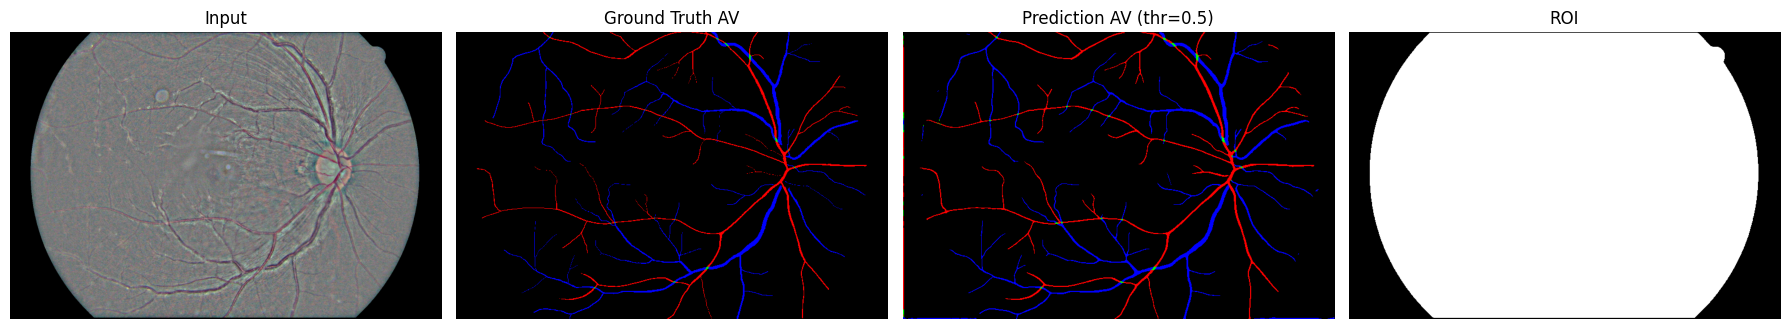

In [31]:
visualize_av_prediction(model, train_loader, threshold=0.5)

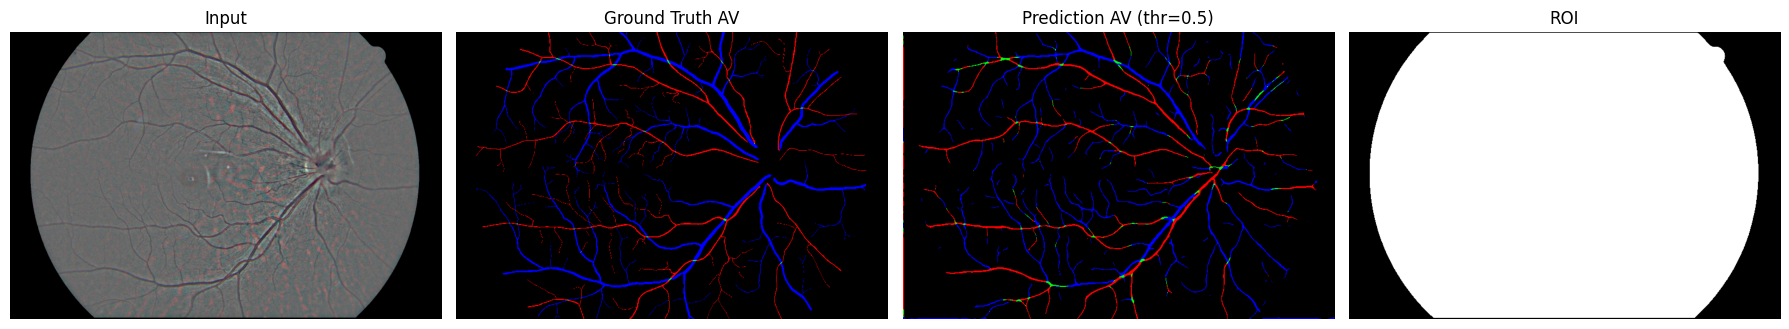

In [32]:
visualize_av_prediction(model, val_loader, threshold=0.5)

In [25]:
images, targets, rois = next(iter(train_loader))

print("Artery ratio:", targets[:,0].mean().item())
print("Vein ratio:", targets[:,1].mean().item())
print("Vessel ratio:", targets[:,2].mean().item())

Artery ratio: 0.02666219137609005
Vein ratio: 0.03551991656422615
Vessel ratio: 0.06157175824046135


In [26]:
model.eval()

images = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images)

pred = outputs[-1]
print(pred.min().item(), pred.max().item(), pred.mean().item())

-138.42584228515625 16.941608428955078 -21.75179672241211


In [27]:
pred_sig = torch.sigmoid(outputs[-1])

print(pred_sig.min().item())
print(pred_sig.max().item())
print(pred_sig.mean().item())

0.0
1.0
0.06464947015047073


In [28]:
binary = (pred_sig > 0.5).float()

print(binary[:,0].sum().item())
print(binary[:,1].sum().item())
print(binary[:,2].sum().item())

15911.0
19438.0
35248.0


# AV Prediction Visualization (RRWNet on GAVE2)

This section visualizes the model prediction against the ground truth artery vein annotation.

### Color Convention (same as GAVE2)
- **Red** → Artery  
- **Blue** → Vein  
- **Green** → Overlap / Crossing  

### Visualization Includes
1. Input Fundus Image  
2. Ground Truth AV Annotation  
3. Predicted AV Annotation  
4. ROI Mask  

### Workflow
1. Take a batch/sample from dataloader  
2. Run forward pass through RRWNet  
3. Take final recursive prediction (`outputs[-1]`)  
4. Apply sigmoid to convert logits → probabilities  
5. Threshold artery and vein channels  
6. Convert both GT and prediction into RGB AV format  
7. Display side by side  

### Notes
- Prediction visualization uses only:
  - Channel 0 → Artery  
  - Channel 1 → Vein  
- Channel 2 (Vessel Tree) is ignored for AV RGB rendering.
- If predictions look blank in early epochs, lower threshold from `0.5` to `0.3`.
- During early training, probability maps may provide better insight than thresholded AV maps.

---

## Utility Function: Convert Tensor to AV RGB

Converts:
- `[3, H, W]` tensor  
to
- RGB image in GAVE2 AV format.

Rules:
- Artery only → Red  
- Vein only → Blue  
- Artery + Vein → Green  

---

## Visualization Function

The visualization function:
- Sets model to eval mode
- Fetches sample from dataloader
- Performs inference
- Converts GT and Prediction to RGB AV maps
- Displays results side by side

---

## Usage

### Visualize training sample
```python
visualize_av_prediction(model, train_loader, threshold=0.5)
Visualize validation sample
visualize_av_prediction(model, val_loader, threshold=0.5)
Early training (lower threshold)
visualize_av_prediction(model, train_loader, threshold=0.3)
Expected Behavior During Training
Early Epochs
Sparse or blank prediction
Mostly vessel trunk visible
Few artery vein distinctions
Mid Training
Major vessels visible
AV classification improves
Overlap regions start appearing
Late Training
Clear artery vein separation
Thin vessels visible
Prediction resembles GT annotation